<a href="https://colab.research.google.com/github/leman-cap13/DL_projects/blob/main/Training_Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Glorot Initialization and He Initialization

In [1]:
import torch
import torch.nn as nn

In [2]:
layer=nn.Linear(100,64)
nn.init.xavier_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

In [3]:
layer=nn.Linear(100,64)
nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

In [4]:
import math

def use_lecun_init(m):
    if isinstance(m, nn.Linear):
        fan_in = m.weight.size(1)
        std = math.sqrt(1.0 / fan_in)
        with torch.no_grad():
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()


In [5]:
model = nn.Sequential(
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 20),
    nn.ReLU(),
    nn.Linear(20, 1)
)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
        nn.init.zeros_(module.bias)

model.apply(use_he_init)

print(model)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=20, bias=True)
  (3): ReLU()
  (4): Linear(in_features=20, out_features=1, bias=True)
)


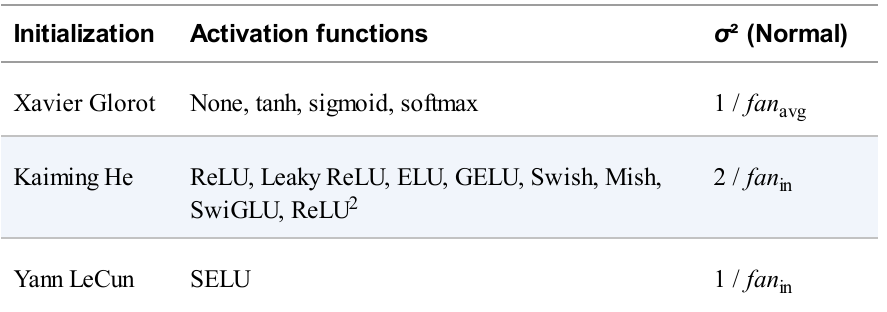

#Better Activation Functions

## ReLU

In [6]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

##LeakyReLU

In [7]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.LeakyReLU(negative_slope=0.2),
    nn.Linear(64, 10)
)

In [8]:
layer = nn.Linear(100, 64)
nn.init.kaiming_uniform_(layer.weight, a=0.2, nonlinearity="leaky_relu")
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

##RReLU = Randomized Leaky ReLU

In [9]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.RReLU(lower=0.1, upper=0.3),
    nn.Linear(64, 10)
)

##PReLU = Parametric Leaky ReLU

In [10]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.PReLU(),
    nn.Linear(64, 10)
)

##ELU

In [59]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ELU(alpha=1.0),
    nn.Linear(64, 10)
)

In [60]:
layer = nn.Linear(100, 64)
nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

##SELU = Scaled ELU

In [61]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.SELU(),
    nn.Linear(64, 10)
)

In [62]:
import math

def use_lecun_init(module):
    if isinstance(module, nn.Linear):
        fan_in = module.weight.size(1)
        std = math.sqrt(1.0 / fan_in)

        with torch.no_grad():
            module.weight.normal_(0, std)
            if module.bias is not None:
                module.bias.zero_()

model.apply(use_lecun_init)

Sequential(
  (0): Linear(in_features=100, out_features=64, bias=True)
  (1): SELU()
  (2): Linear(in_features=64, out_features=10, bias=True)
)

##GELU

In [63]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.GELU(),
    nn.Linear(64, 10)
)

In [64]:
layer = nn.Linear(100, 64)
nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

##Swish / SiLU

In [17]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.SiLU(),
    nn.Linear(64, 10)
)

In [18]:
layer = nn.Linear(100, 64)
nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

##Mish

In [65]:
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.Mish(),
    nn.Linear(64, 10)
)

In [66]:
layer = nn.Linear(100, 64)
nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

In [67]:
x = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])

gelu = nn.GELU()
silu = nn.SiLU()
mish = nn.Mish()

print("x     =", x)
print("GELU  =", gelu(x))
print("SiLU  =", silu(x))
print("Mish  =", mish(x))

x     = tensor([-3., -1.,  0.,  1.,  3.])
GELU  = tensor([-0.0040, -0.1587,  0.0000,  0.8413,  2.9960])
SiLU  = tensor([-0.1423, -0.2689,  0.0000,  0.7311,  2.8577])
Mish  = tensor([-0.1456, -0.3034,  0.0000,  0.8651,  2.9865])



#Implementing batch norm with PyTorch

In [22]:
model = nn.Sequential(
    nn.Flatten(),   # 1*28*28  out  [1,28,28]
    nn.BatchNorm1d(1 * 28 * 28),  #1*28*28 in
    nn.Linear(1 * 28 * 28, 300),   # 300 out
    nn.ReLU(),
    nn.BatchNorm1d(300),  # 300 in
    nn.Linear(300, 100),  # 100 out
    nn.ReLU(),
    nn.BatchNorm1d(100),  # 100 in
    nn.Linear(100, 10)
)

In [23]:
model[1]

BatchNorm1d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [24]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [25]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [26]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

In [27]:
model = nn.Sequential(
nn.Flatten(),
nn.Linear(1 * 28 * 28, 300, bias=False),
nn.BatchNorm1d(300),
nn.ReLU(),
nn.Linear(300, 100, bias=False),
nn.BatchNorm1d(100),
nn.ReLU(),
nn.Linear(100, 10)
)

#Layer Normalization

In [28]:
inputs = torch.randn(32, 3, 100, 200)
layer_norm = nn.LayerNorm([100, 200])
result = layer_norm(inputs)

In [29]:
means = inputs.mean(dim=[2, 3], keepdim=True)
vars_ = inputs.var(dim=[2, 3], keepdim=True, unbiased=False)
stds = torch.sqrt(vars_ + layer_norm.eps)
result = layer_norm.weight * (inputs - means) / stds + layer_norm.bias


In [30]:
layer_norm = nn.LayerNorm([3, 100, 200])
result = layer_norm(inputs)

#Testing On Dataset

In [31]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 64
learning_rate = 1e-3
epochs = 5
alpha = 0.2


transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.48MB/s]


In [33]:
model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(28 * 28, 256, bias=False),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(negative_slope=alpha),

    nn.Linear(256, 128, bias=False),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(negative_slope=alpha),

    nn.Linear(128, 10)
).to(device)

In [34]:
def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(
            module.weight,
            a=alpha,
            nonlinearity="leaky_relu"
        )
        if module.bias is not None:
            nn.init.zeros_(module.bias)

model.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=False)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=128, bias=False)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): LeakyReLU(negative_slope=0.2)
  (7): Linear(in_features=128, out_features=10, bias=True)
)

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [36]:
for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)



        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss /= total
test_acc = correct / total

print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch [1/5] | Loss: 0.4489 | Train Acc: 0.8401
Epoch [2/5] | Loss: 0.3481 | Train Acc: 0.8731
Epoch [3/5] | Loss: 0.3131 | Train Acc: 0.8855
Epoch [4/5] | Loss: 0.2920 | Train Acc: 0.8913
Epoch [5/5] | Loss: 0.2725 | Train Acc: 0.8993

Test Loss: 0.3463 | Test Acc: 0.8726


In [37]:
model[2]

BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [38]:
model[2].running_var

tensor([1.3899, 1.4002, 1.1684, 3.7572, 0.6135, 1.7411, 1.2490, 1.0514, 1.3590,
        2.1352, 1.4272, 1.9287, 2.5116, 2.0430, 1.6184, 2.4314, 1.5632, 2.2013,
        1.6806, 0.5572, 1.3604, 0.9615, 1.9111, 1.5618, 1.4191, 0.8621, 2.1356,
        2.4012, 1.0675, 1.0698, 1.2414, 4.7206, 2.2517, 1.9521, 1.2832, 0.7235,
        2.4807, 4.5847, 1.3256, 3.0182, 1.0280, 1.2797, 2.0113, 5.1588, 1.3412,
        0.6140, 1.0939, 0.9570, 0.7945, 0.6187, 2.8090, 4.7925, 1.5958, 1.5756,
        1.1374, 1.4475, 1.9440, 2.0955, 2.5119, 3.5976, 1.6484, 2.0470, 1.7479,
        1.3954, 1.1678, 1.1392, 2.9510, 1.1721, 0.9199, 1.5145, 1.2092, 2.0782,
        2.5357, 1.8478, 2.1292, 1.0025, 3.9890, 1.0766, 3.6712, 1.2199, 1.2926,
        2.8263, 1.1099, 1.6752, 2.1513, 3.2981, 3.0612, 2.0384, 1.2739, 0.8855,
        1.0413, 1.5575, 0.8311, 0.9389, 1.3966, 2.1918, 1.1625, 2.7675, 1.4614,
        1.5326, 1.9472, 2.3162, 1.9441, 0.9270, 2.0564, 2.9748, 2.6134, 1.5274,
        1.2218, 1.3368, 2.0376, 1.7067, 

In [39]:
model[2].running_mean.shape

torch.Size([256])

In [40]:
print(dict(model[2].named_buffers()).keys())

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])


In [41]:
print(model[2].num_batches_tracked)

tensor(4690)


#Gradient Clipping

In [42]:
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

tensor(0.)

In [56]:
# nn.utils.clip_grad_value_(model.parameters(), clip_value=0.5)

In [52]:
n_epochs = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [55]:
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()   # important for CrossEntropyLoss


        y_pred = model(X_batch)               # shape: [64, 10]
        loss = loss_fn(y_pred, y_batch)       # y_batch shape: [64]

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

#Reusing Pretrained Layers / Transfer Learning with PyTorch


In [106]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import random
import numpy as np


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


transform = transforms.ToTensor()

train_full = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_full = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# 0 = T-shirt/top
# 1 = Trouser
# 2 = Pullover
# 3 = Dress
# 4 = Coat
# 5 = Sandal
# 6 = Shirt
# 7 = Sneaker
# 8 = Bag
# 9 = Ankle boot


taskA_classes = [1, 3, 4, 5, 6, 7, 8, 9]

taskA_label_map = {old_label: new_label for new_label, old_label in enumerate(taskA_classes)}

def get_taskA_indices(dataset):
    indices = []
    for i, label in enumerate(dataset.targets):
        if int(label) in taskA_classes:
            indices.append(i)
    return indices

taskA_train_indices = get_taskA_indices(train_full)
taskA_test_indices = get_taskA_indices(test_full)

taskA_train_dataset = Subset(train_full, taskA_train_indices)
taskA_test_dataset = Subset(test_full, taskA_test_indices)

print("Task A train size:", len(taskA_train_dataset))
print("Task A test size :", len(taskA_test_dataset))
print("Task A label map :", taskA_label_map)


taskB_classes = [0, 2]

def get_taskB_indices(dataset):
    indices = []
    for i, label in enumerate(dataset.targets):
        if int(label) in taskB_classes:
            indices.append(i)
    return indices

taskB_train_all_indices = get_taskB_indices(train_full)
taskB_test_indices = get_taskB_indices(test_full)

taskB_test_dataset = Subset(test_full, taskB_test_indices)

print("Task B full train candidate size:", len(taskB_train_all_indices))
print("Task B test size                :", len(taskB_test_dataset))


def make_small_taskB_train_subset(dataset, n_per_class=10, seed=42):
    rng = random.Random(seed)

    tshirt_indices = []
    pullover_indices = []

    for i, label in enumerate(dataset.targets):
        label = int(label)
        if label == 0:
            tshirt_indices.append(i)
        elif label == 2:
            pullover_indices.append(i)

    selected_tshirt = rng.sample(tshirt_indices, n_per_class)
    selected_pullover = rng.sample(pullover_indices, n_per_class)

    selected_indices = selected_tshirt + selected_pullover
    rng.shuffle(selected_indices)

    return Subset(dataset, selected_indices)

taskB_train_dataset = make_small_taskB_train_subset(train_full, n_per_class=10, seed=42)

print("Task B small train size:", len(taskB_train_dataset))


def map_taskA_labels(labels):
    """
    Task A:
    original labels [1,3,4,5,6,7,8,9]
    -> new labels [0,1,2,3,4,5,6,7]
    """
    return torch.tensor(
        [taskA_label_map[int(label)] for label in labels],
        dtype=torch.long
    )

def map_taskB_labels(labels):
    """
    Task B:
    0 (T-shirt/top) -> 1.0
    2 (Pullover)    -> 0.0
    """
    return torch.tensor(
        [1.0 if int(label) == 0 else 0.0 for label in labels],
        dtype=torch.float32
    ).unsqueeze(1)

Task A train size: 48000
Task A test size : 8000
Task A label map : {1: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7}
Task B full train candidate size: 12000
Task B test size                : 2000
Task B small train size: 20


In [107]:

taskA_train_loader = DataLoader(
    taskA_train_dataset,
    batch_size=128,
    shuffle=True)


taskA_test_loader = DataLoader(
    taskA_test_dataset,
    batch_size=128,
    shuffle=False)

taskB_train_loader = DataLoader(
    taskB_train_dataset,
    batch_size=4,
    shuffle=True)


taskB_test_loader = DataLoader(
    taskB_test_dataset,
    batch_size=256,
    shuffle=False)

In [108]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
).to(device)

print(model_A)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)


In [109]:
torch.manual_seed(42)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

In [110]:
criterion_A = nn.CrossEntropyLoss()
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=1e-3)

In [111]:
criterion_B = nn.BCEWithLogitsLoss()
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=1e-3)

In [112]:
def train_taskA(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = map_taskA_labels(y).to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    print(f"Train Task A | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")

In [113]:
train_taskA(
    model_A,
    taskA_train_loader,
    optimizer_A,
    criterion_A
)

Train Task A | Loss: 0.4792 | Acc: 0.8266


In [114]:
def train_taskB(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = map_taskB_labels(y).to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        total_correct += (preds == y).sum().item()
        total_samples += y.numel()

    avg_loss = total_loss / len(loader.dataset)
    avg_acc = total_correct / total_samples
    print(f"Train Task B | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")

In [115]:
train_taskB(
    model_B,
    taskB_train_loader,
    optimizer_B,
    criterion_B
)

Train Task B | Loss: 0.7056 | Acc: 0.6000


In [116]:
import copy

torch.manual_seed(42)

reused_layers = copy.deepcopy(model_A[:-1])

model_B_on_A = nn.Sequential(
    *reused_layers,
    nn.Linear(100, 1)
).to(device)

print(model_B_on_A)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)


In [117]:
for layer in model_B_on_A[:-1]:
    for param in layer.parameters():
        param.requires_grad = False

In [118]:
xentropy = nn.BCEWithLogitsLoss()

In [120]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.8 MB/s eta 0:00:00


In [121]:
import torchmetrics

In [122]:
accuracy = torchmetrics.Accuracy(task="binary").to(device)

In [125]:
optimizer_B_on_A = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_B_on_A.parameters()),
    lr=1e-4
)

In [124]:
for param in model_B_on_A.parameters():
    param.requires_grad = True

In [127]:
for epoch in range(5):
    print(f"Frozen phase epoch {epoch+1}")
    train_taskB(model_B_on_A, taskB_train_loader, optimizer_B_on_A, xentropy)

Frozen phase epoch 1
Train Task B | Loss: 0.7388 | Acc: 0.5000
Frozen phase epoch 2
Train Task B | Loss: 0.6688 | Acc: 0.6000
Frozen phase epoch 3
Train Task B | Loss: 0.6143 | Acc: 0.6500
Frozen phase epoch 4
Train Task B | Loss: 0.5775 | Acc: 0.8500
Frozen phase epoch 5
Train Task B | Loss: 0.5536 | Acc: 0.9000


In [128]:
for param in model_B_on_A.parameters():
    param.requires_grad = True

In [129]:
optimizer_B_on_A = torch.optim.Adam(
    model_B_on_A.parameters(),
    lr=1e-4
)

In [130]:
for epoch in range(10):
    print(f"Fine-tune phase epoch {epoch+1}")
    train_taskB(model_B_on_A, taskB_train_loader, optimizer_B_on_A, xentropy)

Fine-tune phase epoch 1
Train Task B | Loss: 0.5412 | Acc: 0.9500
Fine-tune phase epoch 2
Train Task B | Loss: 0.5082 | Acc: 0.8500
Fine-tune phase epoch 3
Train Task B | Loss: 0.4698 | Acc: 0.9500
Fine-tune phase epoch 4
Train Task B | Loss: 0.4449 | Acc: 0.9500
Fine-tune phase epoch 5
Train Task B | Loss: 0.4179 | Acc: 0.9500
Fine-tune phase epoch 6
Train Task B | Loss: 0.3902 | Acc: 0.9500
Fine-tune phase epoch 7
Train Task B | Loss: 0.3655 | Acc: 0.9500
Fine-tune phase epoch 8
Train Task B | Loss: 0.3406 | Acc: 0.9500
Fine-tune phase epoch 9
Train Task B | Loss: 0.3190 | Acc: 0.9500
Fine-tune phase epoch 10
Train Task B | Loss: 0.3001 | Acc: 1.0000


#Unsupervised Pretraining


In [26]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [27]:
device

'cpu'

In [28]:
X,y=load_digits(return_X_y=True)
X=X.astype(np.float32) / 16.0
y=y.astype(np.int64)

In [29]:
X

array([[0.    , 0.    , 0.3125, ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.625 , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 1.    , 0.5625, 0.    ],
       ...,
       [0.    , 0.    , 0.0625, ..., 0.375 , 0.    , 0.    ],
       [0.    , 0.    , 0.125 , ..., 0.75  , 0.    , 0.    ],
       [0.    , 0.    , 0.625 , ..., 0.75  , 0.0625, 0.    ]],
      dtype=float32)

In [30]:
X.shape

(1797, 64)

In [31]:
import matplotlib.pyplot as plt

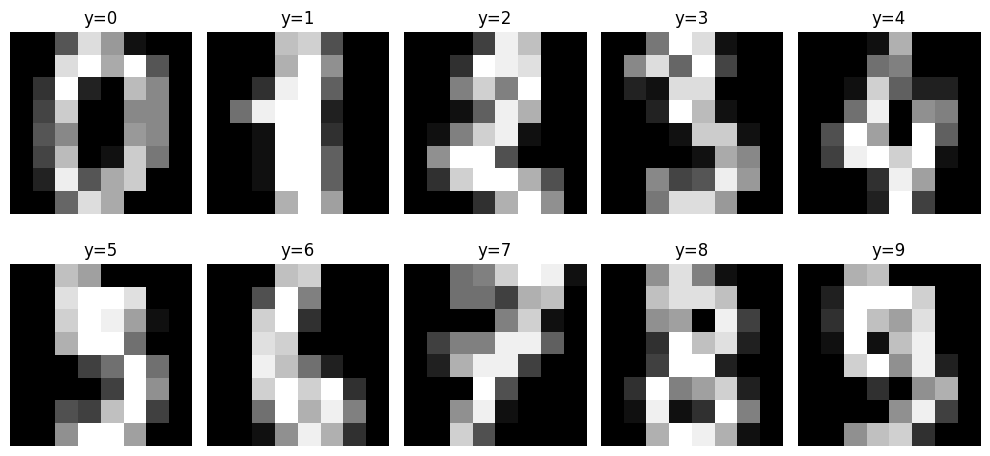

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"y={y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [40]:
labeled_idx = []
for c in range(10):
    idx = np.where(y_train == c)[0]
    np.random.shuffle(idx)
    labeled_idx.extend(idx[:3])

labeled_idx = np.array(labeled_idx)

X_labeled = X_train[labeled_idx]
y_labeled = y_train[labeled_idx]

In [41]:
X_labeled

array([[0.    , 0.    , 0.125 , ..., 0.4375, 0.    , 0.    ],
       [0.    , 0.    , 0.25  , ..., 0.25  , 0.    , 0.    ],
       [0.    , 0.    , 0.4375, ..., 0.1875, 0.    , 0.    ],
       ...,
       [0.    , 0.    , 0.1875, ..., 0.9375, 0.    , 0.    ],
       [0.    , 0.    , 0.3125, ..., 0.625 , 0.    , 0.    ],
       [0.    , 0.    , 0.125 , ..., 0.75  , 0.    , 0.    ]],
      dtype=float32)

In [42]:
y_labeled

array([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 7,
       7, 7, 8, 8, 8, 9, 9, 9])

In [43]:

X_unlabeled = X_train.copy()

labeled_loader = DataLoader(
    TensorDataset(torch.tensor(X_labeled), torch.tensor(y_labeled)),
    batch_size=16, shuffle=True
)

unlabeled_loader = DataLoader(
    TensorDataset(torch.tensor(X_unlabeled)),
    batch_size=64, shuffle=True
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=256
)

In [44]:
print("Labeled sample sayı:", len(X_labeled))
print("Unlabeled sample sayı:", len(X_unlabeled))
print("Test sample sayı:", len(X_test))


Labeled sample sayı: 30
Unlabeled sample sayı: 1257
Test sample sayı: 540


In [45]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [46]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.head = nn.Linear(16, 10)

    def forward(self, x):
        x = self.feature(x)
        x = self.head(x)
        return x

In [47]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

In [48]:
def train_classifier(model, epochs=50, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in labeled_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()


def pretrain_autoencoder(model, epochs=30, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for (xb,) in unlabeled_loader:
            xb = xb.to(device)

            optimizer.zero_grad()
            x_hat = model(xb)
            loss = loss_fn(x_hat, xb)
            loss.backward()
            optimizer.step()

In [49]:
baseline = Classifier().to(device)
train_classifier(baseline, epochs=80, lr=1e-3)
baseline_acc = evaluate(baseline)

In [50]:

print("Baseline accuracy:", round(baseline_acc, 4))

Baseline accuracy: 0.6833


In [51]:
ae = Autoencoder().to(device)
pretrain_autoencoder(ae, epochs=40, lr=1e-3)

In [52]:
model = Classifier().to(device)

model.feature.load_state_dict(ae.encoder.state_dict())

<All keys matched successfully>

In [55]:
for p in model.feature.parameters():
    p.requires_grad = False

train_classifier(model, epochs=30, lr=1e-2)

for p in model.feature.parameters():
    p.requires_grad = False

for p in model.feature[2].parameters():
    p.requires_grad = True



train_classifier(model, epochs=50, lr=1e-3)

pretrained_acc = evaluate(model)

print("Pretrain + fine-tune accuracy:", round(pretrained_acc, 4))
print("Fərq:", round(pretrained_acc - baseline_acc, 4))

Pretrain + fine-tune accuracy: 0.837
Fərq: 0.1537
